In [1]:
import dtreeviz
import graphviz
print("dtreeviz import 성공")
print("graphviz import 성공")

dtreeviz import 성공
graphviz import 성공


In [2]:
import os

graphviz_bin = r"C:\Program Files\Graphviz\bin"

os.environ["PATH"] = graphviz_bin + os.pathsep + os.environ["PATH"]

print("Graphviz PATH 추가 완료:")
print(graphviz_bin)

Graphviz PATH 추가 완료:
C:\Program Files\Graphviz\bin


In [3]:
# SVG 생성 전에 Matplotlib 한글 폰트 설정
# 중요: 이 셀은 dtreeviz SVG를 만들기 전에 ***반드시*** 실행해야 한다
import matplotlib as mpl
import matplotlib.pyplot as plt
# 핵심설정1: 한글 폰트 사용
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
# 핵심설정2: SVG에서 글자를 path로 바꾸지 않고 text로 남김
# 이 설정이 없으면 한글이 ArialMT-xxxx path로 변환되어 깨질 수 있습니다.
mpl.rcParams["svg.fonttype"] = "none"

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
import time

# 학습/검증 데이터를 나누는 함수
from sklearn.model_selection import train_test_split
# 하이퍼파라미터 후보를 무작위로 탐색하는 도구
from sklearn.model_selection import RandomizedSearchCV
# 컬럼 종류별로 다른 전처리를 한번에 적용하는 도구
from sklearn.compose import ColumnTransformer
# 전처리와 모델 학습을 하나의 흐름으로 묶는 도구
from sklearn.pipeline import Pipeline
# 범주형(문자) 값을 0/1 형태의 숫자 컬럼으로 펼치는 도구
from sklearn.preprocessing  import OneHotEncoder
# 회귀 모델 평가 지표들 (MAE, MSE_>RMSE, R2)
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 숫자 값을 예측하는 회귀용 XGBoost 모델
from xgboost import XGBRegressor

# 안내성 경고 메시지를 숨겨 수업 흐름의 가독성을 높입니다. (오류가 아니라 경고입니다.)
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("jeju_bus.csv")
print("jeju_bus.csv 를 정상적으로 불러왔습니다.")

jeju_bus.csv 를 정상적으로 불러왔습니다.


In [6]:
df.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


In [7]:
df_model = df.copy()

target_col = "next_arrive_time"

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


In [8]:
df_model[["date", "now_arrive_time"]].head()

,date,now_arrive_time
0,2019-10-15,06시
1,2019-10-15,06시
2,2019-10-15,06시
3,2019-10-15,06시
4,2019-10-15,07시


In [9]:
df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")

df_model["year"] = df_model["date"].dt.year
df_model["month"] = df_model["date"].dt.month
df_model["day"] = df_model["date"].dt.day
df_model["dayofweek"] = df_model["date"].dt.dayofweek

df_model["now_hour"] = df_model["now_arrive_time"].astype(str).str.extract(r"(\d+)").astype(float)

df_model[["date", "day", "dayofweek", "now_arrive_time", "now_hour"]].head()

,date,day,dayofweek,now_arrive_time,now_hour
0,2019-10-15,15,1,06시,6.0
1,2019-10-15,15,1,06시,6.0
2,2019-10-15,15,1,06시,6.0
3,2019-10-15,15,1,06시,6.0
4,2019-10-15,15,1,07시,7.0


In [10]:
def calculate_distance_km(lat1, lon1, lat2, lon2):
    
    earth_radius_km = 6371

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (np.sin(dlat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

In [11]:
reference_points = {
    "up": (33.506286, 126.490312),
    "down": (33.246742, 126.562387),
    "right": (33.493521, 126.895326),
    "center": (33.379724, 126.545315)
}

In [12]:
def assign_region_info(data, lat_col, lon_col):

    #1. 각 기준점의 위도/경도 값을 꺼냅니다.
    up_lat, up_lon = reference_points["up"]
    down_lat, down_lon = reference_points["down"]
    right_lat, right_lon = reference_points["right"]
    center_lat, center_lon = reference_points["center"]

    #2. 각 정류장에서 4개 기준점까지의 거리를 계산합니다.
    distance_to_up = calculate_distance_km(data[lat_col], data[lon_col], up_lat, up_lon)
    distance_to_down = calculate_distance_km(data[lat_col], data[lon_col], down_lat, down_lon)
    distance_to_right = calculate_distance_km(data[lat_col], data[lon_col], right_lat, right_lon)
    distance_to_center = calculate_distance_km(data[lat_col], data[lon_col], center_lat, center_lon)
    
    #3. 가장 가까운 권역 이름을 찾기 위한 거리표를 만듭니다.
    #여기서는 컬럼명을 up, down, right, center로 둬야
    #idxmin(axis=1)의 결과가 바로 권역 이름이 됩니다.
    distance_table = pd.DataFrame({
        "up": distance_to_up,
        "down": distance_to_down,
        "right": distance_to_right,
        "center": distance_to_center
    }, index = data.index)

    #4. 각 행에서 가장 가까운 기준점 이름을 찾습니다.
    nearest_region = distance_table.idxmin(axis=1)

    #5. 최종 반환용 DataFrame을 만듭니다.
    #거리 컬럼명은 모델 feature로 쓰기 좋게 명확하게 작성
    result = pd.DataFrame({
        "dist_name": nearest_region,
        "dist_to_up": distance_to_up,
        "dist_to_down": distance_to_down,
        "dist_to_right": distance_to_right,
        "dist_to_center": distance_to_center
    }, index = data.index)

    return result

In [13]:
now_region_info = assign_region_info(
    df_model,
    "now_latitude",
    "now_longitude"
)

now_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,7.962505,23.319056,32.135034,8.532122
1,up,8.003869,23.473015,31.905930,8.710701
2,up,8.158338,23.582519,31.583874,8.861671
3,up,5.774762,25.961685,32.635035,11.118256
4,up,2.332803,27.295447,37.141639,12.673969


In [14]:
next_region_info = assign_region_info(
    df_model,
    "next_latitude",
    "next_longitude"
)

next_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,8.003869,23.473015,31.905930,8.710701
1,up,8.158338,23.582519,31.583874,8.861671
2,up,8.387595,23.701416,31.175511,9.041978
3,up,5.429627,26.539110,32.693959,11.692688
4,up,2.276139,27.400941,37.514443,12.832868


In [15]:
df_model["now_dist_name"] = now_region_info["dist_name"]
df_model["now_dist_to_up"] = now_region_info["dist_to_up"]
df_model["now_dist_to_down"] = now_region_info["dist_to_down"]
df_model["now_dist_to_right"] = now_region_info["dist_to_right"]
df_model["now_dist_to_center"] = now_region_info["dist_to_center"]

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,year,month,day,dayofweek,now_hour,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,2019,10,15,1,6.0,up,7.962505,23.319056,32.135034,8.532122
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,2019,10,15,1,6.0,up,8.003869,23.473015,31.905930,8.710701
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,2019,10,15,1,6.0,up,8.158338,23.582519,31.583874,8.861671
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,2019,10,15,1,6.0,up,5.774762,25.961685,32.635035,11.118256
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,2019,10,15,1,7.0,up,2.332803,27.295447,37.141639,12.673969


In [16]:
df_model["next_dist_name"] = next_region_info["dist_name"]
df_model["next_dist_to_up"] = next_region_info["dist_to_up"]
df_model["next_dist_to_down"] = next_region_info["dist_to_down"]
df_model["next_dist_to_right"] = next_region_info["dist_to_right"]
df_model["next_dist_to_center"] = next_region_info["dist_to_center"]

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,up,7.962505,23.319056,32.135034,8.532122,up,8.003869,23.473015,31.905930,8.710701
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,up,8.003869,23.473015,31.905930,8.710701,up,8.158338,23.582519,31.583874,8.861671
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,up,8.158338,23.582519,31.583874,8.861671,up,8.387595,23.701416,31.175511,9.041978
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,up,5.774762,25.961685,32.635035,11.118256,up,5.429627,26.539110,32.693959,11.692688
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,up,2.332803,27.295447,37.141639,12.673969,up,2.276139,27.400941,37.514443,12.832868


In [17]:
# 현재 정류장 권역과 다음 정류장 권역을 조합한 feature 생성
df_model["dist_segment_name"] = (
    df_model["now_dist_name"].astype(str) + " -> " + df_model["next_dist_name"].astype(str)
)
df_model

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center,dist_segment_name
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,7.962505,23.319056,32.135034,8.532122,up,8.003869,23.473015,31.905930,8.710701,up -> up
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,8.003869,23.473015,31.905930,8.710701,up,8.158338,23.582519,31.583874,8.861671,up -> up
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,8.158338,23.582519,31.583874,8.861671,up,8.387595,23.701416,31.175511,9.041978,up -> up
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,5.774762,25.961685,32.635035,11.118256,up,5.429627,26.539110,32.693959,11.692688,up -> up
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,2.332803,27.295447,37.141639,12.673969,up,2.276139,27.400941,37.514443,12.832868,up -> up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528.0,...,29.005930,1.724127,39.624369,14.101369,down,29.345088,1.256942,40.123236,14.468773,down -> down
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280.0,...,29.560001,0.607018,40.775774,14.739550,down,29.377265,0.471628,40.867894,14.578870,down -> down
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114.0,...,29.024374,0.604451,41.106369,14.282445,down,29.096335,0.550141,41.217986,14.365152,down -> down
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223.0,...,29.096335,0.550141,41.217986,14.365152,down,29.237779,0.505603,41.437302,14.528214,down -> down


In [18]:
# 조합 권역이 몇 종류인지, 어떤 조합이 많은지 확인
print("dist_segment_name 고유값 개수:", df_model["dist_segment_name"].nunique())
df_model["dist_segment_name"].value_counts()

dist_segment_name 고유값 개수: 12


dist_segment_name
up -> up            121131
down -> down         48377
right -> right       34032
center -> center      5512
center -> up           321
right -> up            276
up -> center           207
down -> right          144
up -> right            137
right -> down          134
down -> center          95
center -> down          91
Name: count, dtype: int64

In [19]:
# 이번 노트북에서 고정할 최종 후보 feature
# (v2_original 기본 feature + 위치 관련 거리 feature + dist_segment_name)
# 숫자형/범주형을 나누는 이유: 범주형(문자)만 One-Hot Encoding 으로 숫자 컬럼으로 바꿔야 모델이 쓸 수 있기 때문
selected_numeric_features = [
    "distance",
    "day",
    "dayofweek",
    "now_hour",
    "now_dist_to_up",
    "now_dist_to_down",
    "now_dist_to_right",
    "now_dist_to_center",
    "next_dist_to_up",
    "next_dist_to_down",
    "next_dist_to_right",
    "next_dist_to_center"
]

In [20]:
selected_categorical_features = [
    "route_nm",
    "now_station",
    "next_station",
    "dist_segment_name"
]

In [21]:
selected_features = selected_numeric_features + selected_categorical_features

selected_features

['distance',
 'day',
 'dayofweek',
 'now_hour',
 'now_dist_to_up',
 'now_dist_to_down',
 'now_dist_to_right',
 'now_dist_to_center',
 'next_dist_to_up',
 'next_dist_to_down',
 'next_dist_to_right',
 'next_dist_to_center',
 'route_nm',
 'now_station',
 'next_station',
 'dist_segment_name']

In [22]:
upper_1pct = df_model[target_col].quantile(0.99)

upper_1pct

np.float64(340.0)

In [23]:
df_model_selected = df_model[df_model[target_col] <= upper_1pct].copy()

print("원본 데이터 행 수:", len(df_model))
print("상위 1% target 제거 후 행 수:", len(df_model_selected))
print("제거된 행 수:", len(df_model) - len(df_model_selected))
print("상위 1% 제거 기준값:", upper_1pct)

원본 데이터 행 수: 210457
상위 1% target 제거 후 행 수: 208355
제거된 행 수: 2102
상위 1% 제거 기준값: 340.0


In [24]:
X = df_model_selected[selected_features]
y = df_model_selected[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("학습용 크기:", X_train.shape, "/ 검증용 크기:", X_test.shape)

학습용 크기: (166684, 16) / 검증용 크기: (41671, 16)


In [25]:
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), selected_categorical_features)],
    remainder="passthrough"
)

print("전처리기(preprocessor) 준비 완료 (앞 노트북과 동일한 구성)")

전처리기(preprocessor) 준비 완료 (앞 노트북과 동일한 구성)


In [26]:
def evaluate_regression_model(model_name, description, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    # RMSE 는 일부 버전에서 squared=False 옵션이 없으므로, 호환성을 위해 np.sqrt로 직접 계산
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"[{model_name}] MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    # 나중에 여러 모델 결과를 한 표로 모이기 좋도록 딕셔너리로 반환
    return{
        "model_name":model_name, "description": description, 
        "MAE": mae, "RMSE": rmse
    }

In [27]:
def train_xgb_pipeline(model_name, description, xgb_params):
    # 전달받은 하이퍼파라미터로 XGBoost 회귀 모델을 만듭니다.
    # 수동 튜닝에서는 한 번에 한 모델만 학습하므로 n_jobs=-1로 CPU를 충분히 사용합니다.
    xgb_model = XGBRegressor(
        objective="reg:squarederror",   # 회귀: 제곱 오차를 줄이도록 학습
        random_state=42,                # 재현성 확보
        n_jobs=-1,                      # 가용 CPU 최대 사용 (수동 튜닝에서는 안전)
        **xgb_params                    # 실험마다 달라지는 하이퍼파라미터
    )

    # 고정된 전처리기와 모델을 하나의 파이프라인으로 묶기
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ])

    # 같은 X_train, y_train으로 학습 (split 고정)    
    model_pipeline.fit(X_train, y_train)
    # 같은 X_test로 예측합니다.
    y_pred = model_pipeline.predict(X_test)

    # 평가 결과 만들기
    evaluation = evaluate_regression_model(
        model_name=model_name,
        description=description,
        y_true=y_test,
        y_pred=y_pred
    )

    return {
        "model_name": model_name,
        "pipeline": model_pipeline,
        "y_pred": y_pred,
        "evaluation": evaluation
    }

In [28]:
# 선정 조건 기준 모델의 하이퍼파라미터 (기본 설정)
base_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 5
}

# 기준 모델을 학습하고 평가합니다. 이후 모든 튜닝 모델은 이 모델과 비교합니다.
selected_base_result = train_xgb_pipeline(
    model_name="selected_base_xgb",
    description="선정 조건 기준 모델 (v2 + 위치 feature + 상위 1% 제거, 기본 파라미터)",
    xgb_params=base_params
)

[selected_base_xgb] MAE: 22.0203 | RMSE: 30.3539


In [29]:
# (1) shallow_xgb: 깊이를 3으로 줄여 더 단순한 모델을 만듭니다.
shallow_result = train_xgb_pipeline(
    model_name="shallow_xgb",
    description="얕은 트리 (max_depth=3) - 단순한 모델",
    xgb_params={"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3}
)

[shallow_xgb] MAE: 24.6185 | RMSE: 33.1101


In [30]:
# (2) deep_xgb: 깊이를 8로 늘려 더 복잡한 모델을 만듭니다
deep_result = train_xgb_pipeline(
    model_name="deep_xgb",
    description="깊은 트리 (max_depth=8) - 복잡한 모델",
    xgb_params={"n_estimators": 200, "learning_rate": 0.05, "max_depth": 8}
)

[deep_xgb] MAE: 19.7910 | RMSE: 28.3630


In [31]:
# (3) slow_learning_xgb: 학습률을 낮추고(0.03) 트리 수를 늘려(400) 천천히 더 많이 학습합니다.
slow_learning_result = train_xgb_pipeline(
    model_name="slow_learning_xgb",
    description="천천히 많이 학습 (lr=0.03, n_estimators=400)",
    xgb_params={"n_estimators": 400, "learning_rate": 0.03, "max_depth": 5}
)

[slow_learning_xgb] MAE: 21.8065 | RMSE: 30.1558


In [32]:
# regularized_xgb: 샘플링 + 규제로 과적합을 완화하는 설정
regularized_result = train_xgb_pipeline(
    model_name="regularized_xgb",
    description="과적합 완화 (subsample/colsample + reg_alpha/reg_lambda)",
    xgb_params={
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 8,
        "subsample": 0.8,           # 트리마다 행의 80%만 랜덤하게 매번 다르게 선택해서 사용
        "colsample_bytree": 0.8,    # 트리마다 feature의 80%만 랜덤하게 매번 다르게 선택해서 사용
        "reg_alpha": 0.01,          # L1 규제 (라쏘회귀)
        "reg_lambda": 1.5           # L2 규제 (릿지회귀)
    }
)

[regularized_xgb] MAE: 19.1184 | RMSE: 27.8349


In [33]:
# fold_df = pd.DataFrame({
#     "distance":         [0.5, 1.0, 0.7, 1.5, 0.3],
#     "now_hour":         [8,   8,   14,  18,  10],
#     "next_arrive_time": [90,  150, 100, 240, 60]
# })
# fold_df

In [34]:
# fold_X = fold_df[["distance", "now_hour"]]
# fold_X

In [35]:
# fold_y = fold_df["next_arrive_time"]
# fold_y

In [36]:
# from sklearn.model_selection import KFold

In [37]:
# kf = KFold(n_splits=5, shuffle=False)

In [38]:
# num = 1

In [39]:
# mae_scores = []
# for train_idx, valid_idx in kf.split(fold_X):
#     print("=" * 30)
#     print(f"num={num}")
#     print(f"train_idx={train_idx}"); print(f"valid_idx={valid_idx}")

#     X_train1 = fold_X.iloc[train_idx]
#     y_train1 = fold_y.iloc[train_idx]
#     print(f"X_train={X_train}"); print(f"y_train={y_train}")

#     X_valid1 = fold_X.iloc[valid_idx]
#     y_valid1 = fold_y.iloc[valid_idx]
#     print(f"X_valid={X_valid1}"); print(f"y_valid={y_valid1}")

#     model = XGBRegressor()
#     model.fit(X_train1, y_train1)
#     y_pred = model.predict(X_valid1)

#     mae=mean_absolute_error(y_valid1, y_pred)
#     print(f"mae={mae}")
#     mae_scores.append(mae)
#     num += 1

In [40]:
# mae_scores

In [41]:
# np.mean(mae_scores)

In [42]:
"""
# 1. 수동 실험할 때 썼던 똑같은 기본 구조로 빈 XGBoost 모델을 만듭니다.
# (어차피 바뀔 파라미터들은 제외하고 고정값만 넣습니다)
base_xgb = XGBRegressor(
    objective="reg:squarederror",   # 회귀 문제 고정
    random_state=42,                # 재현성 고정
    n_jobs=-1
)

# 2. 수동 실험 함수와 동일하게 전처리기와 모델을 파이프라인으로 묶어 'search_model'로 지정합니다.
search_model = Pipeline(steps=[
    ("preprocessor", preprocessor),  # 기존에 정의해둔 preprocessor 객체 사용
    ("model", base_xgb)
])
"""
search_model = Pipeline(steps=[
    ("preprocessor", preprocessor),  # 기존에 정의해둔 preprocessor 객체 사용
    ("model", XGBRegressor(
                objective="reg:squarederror",   # 회귀 문제 고정
                random_state=42,                # 재현성 고정
                n_jobs= 1                       # 중첩 병렬 방지
            )
    )
]) 


# 탐색할 하이퍼파라미터 후보입니다. Pipeline 모델 단계 이름이 "model" 이므로 "model__"을 앞에 붙입니다.
param_distributions= {
    "model__max_depth":[8, 9, 10],
    "model__learning_rate":[0.03, 0.05, 0.1],
    "model__n_estimators":[400, 500],
    "model__subsample":[0.8, 0.9, 1.0],
    "model__colsample_bytree":[0.8, 0.9, 1.0]
}

# MAE는 작을수록 좋으므로, 점수가 클수록 좋은 sklearn 규칙에 맞춰 음수 MAE를 사용합니다.
scoring = "neg_mean_absolute_error"

print("탐색 대상 파라미터 수:", len(param_distributions))

탐색 대상 파라미터 수: 5


In [43]:
# RandomizedSearchCV 를 구성합니다.
random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,
    n_iter=30,                          #시도할 조합 수. 실행이 오래 걸리면 줄일 수 있음
    scoring="neg_mean_absolute_error",  #음수 MAE (클수록 좋음)
    cv=5,                               #train을 5개로 나눠 내부 교차검증
    random_state=42,                    #재현성
    n_jobs=-1,                          #조합 단위 병렬 (바깥 병렬)
    verbose=1                           #진행 상황 출력
)

In [44]:
#학습은 train데이터 안에서만 이루어집니다.(test는 사용하지 않습니다.)
#데이터 규모와 조합 수에 따라 다소 시간이 걸릴 수 있습니다.
start_time = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"RandomizedSearchCV 완료. 소요시간: {elapsed:.1f}초")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RandomizedSearchCV 완료. 소요시간: 364.1초


In [45]:
# 교차검증 기준 가장 좋았던 하이퍼파라미터 조합
random_search.best_params_

{'model__subsample': 0.9,
 'model__n_estimators': 500,
 'model__max_depth': 9,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 0.9}

In [46]:
# 교차검증 기준 가장 좋았던 점수 (음수 MAE 형태)
random_search.best_score_

np.float64(-18.77615394592285)

In [47]:
# 음수 MAE를 양수 MAE로 변환해 해석합니다. (train 내부 교차검증 결과)
best_cv_mae = -random_search.best_score_
print(f"best_cv_mae (train 내부 교차검증 MAE): {best_cv_mae:.4f}")

best_cv_mae (train 내부 교차검증 MAE): 18.7762


In [48]:
# 최적 파라미터로 학습된 모델을 가져옵니다.
best_model = random_search.best_estimator_

# 남겨 둔 test set 으로 예측합니다.
y_pred_best = best_model.predict(X_test)

# test set 기준으로 평가합니다. (튜닝 모델 이름: best_tuned_xgb)
best_result = evaluate_regression_model(
    model_name="best_tuned_xgb",
    description="RandomizedSearchCV로 선택한 최적 XGBoost 모델",
    y_true=y_test,
    y_pred=y_pred_best
)

# train 내부 교차검증 MAE와 test MAE를 나란히 비교합니다.
print(f"best_cv_mae (train 내부 교차검증): {best_cv_mae:.4f}")
print(f"test MAE (남겨 둔 test set): {best_result['MAE']:.4f}")

[best_tuned_xgb] MAE: 18.7165 | RMSE: 27.9148
best_cv_mae (train 내부 교차검증): 18.7762
test MAE (남겨 둔 test set): 18.7165


In [49]:
best_pred_compare_df = pd.DataFrame({
    "actual": y_test.values,
    "pred": y_pred_best,
    "error": y_test.values - y_pred_best,
    "abs_error": np.abs(y_test.values - y_pred_best)
})

In [50]:
best_pred_compare_df.sort_values("abs_error", ascending=False).head(20)

,actual,pred,error,abs_error
8003,300,52.135536,247.864464,247.864464
33792,310,79.869942,230.130058,230.130058
41213,320,94.770004,225.229996,225.229996
9496,82,301.372589,-219.372589,219.372589
8852,320,102.099480,217.900520,217.900520
1910,340,128.750916,211.249084,211.249084
4062,272,62.305004,209.694996,209.694996
27804,328,118.910423,209.089577,209.089577
13709,308,105.739624,202.260376,202.260376
36932,330,130.871750,199.128250,199.128250


In [51]:
# 이미 학습된 최적 모델(best_model)을 그대로 사용합니다. (모델을 새로 학습하지 않습니다.)
# best_model은 (preprocessor -> model) 2단계로 이루어진 Pipeline 입니다.
best_preprocessor = best_model.named_steps["preprocessor"]  # 전처리기(OneHotEncoder 등)
best_xgb_model = best_model.named_steps["model"]            # 실제 XGBoost 모델

# Pipeline 단계 이름을 확인합니다. (단계 이름이 다르면 위 키를 그 이름에 맞게 바꿔야 합니다.)
print("최적 모델 Pipeline 단계:", list(best_model.named_steps.keys()))

최적 모델 Pipeline 단계: ['preprocessor', 'model']


In [52]:
# 전처리(OneHotEncoder + passthrough) 이후 실제 모델에 들어간 feature 이름을 가져오기
transformed_feature_names = best_preprocessor.get_feature_names_out()

# 표를 만들기 전에 두 개수를 반드시 확인합니다. (개수가 다르면 DataFrame 생성에서 오류가 납니다.)
print("전처리 후 feature 개수:", len(transformed_feature_names))
print("XGBoost feature importance 개수:", len(best_xgb_model.feature_importances_))

전처리 후 feature 개수: 743
XGBoost feature importance 개수: 743


In [53]:
# 세부 feature 이름과 중요도를 한 표로 모으고, 중요도가 큰 순으로 정렬합니다.
feature_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": best_xgb_model.feature_importances_,
})
feature_importance_df = feature_importance_df.sort_values(
    "importance", ascending=False
).reset_index(drop=True)

display(feature_importance_df.head(20))

,feature,importance
0,cat__next_station_제주중앙여자고등학교(아라방면),0.084002
1,remainder__next_dist_to_up,0.040678
2,cat__next_station_제주중앙여자고등학교(광양방면),0.039622
3,cat__now_station_성산환승정류장(고성리 회전교차로),0.038387
4,cat__next_station_성판악,0.036422
5,remainder__distance,0.030773
6,cat__dist_segment_name_up -> up,0.028900
7,cat__now_station_원노형,0.028139
8,cat__now_station_농협 하나로마트,0.023696
9,cat__now_station_월성 마을,0.018470


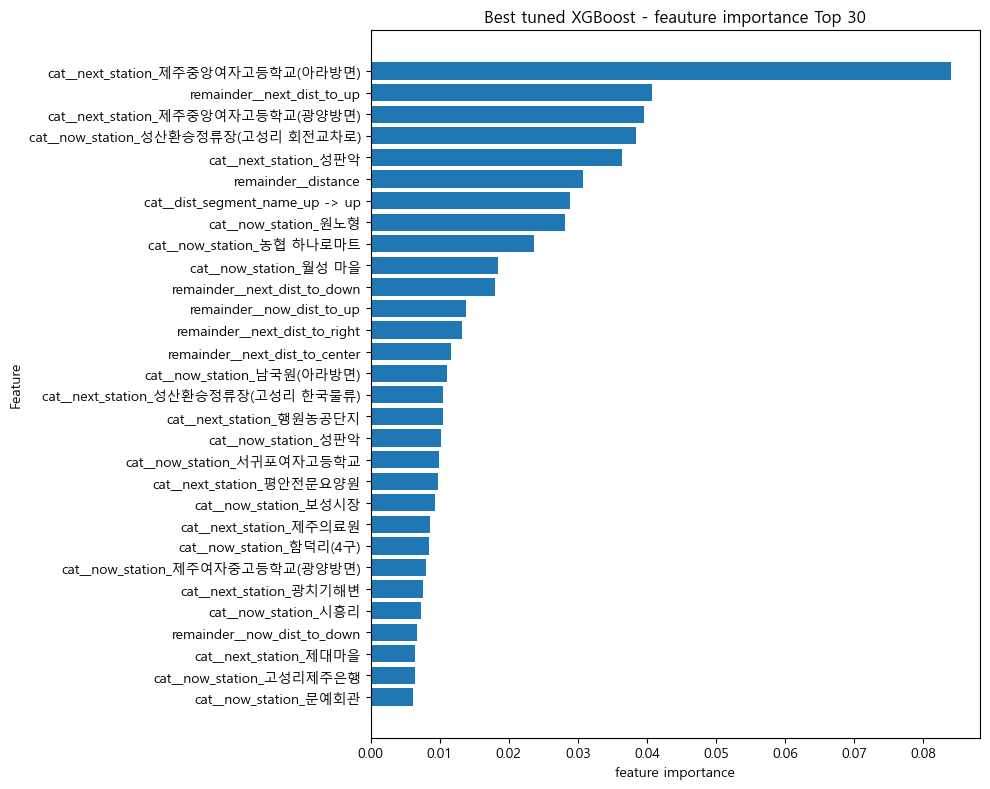

In [54]:
# 상위 30개 feature를 수평 막대그래프로 그립니다.
top_n = 30
# 그래프는 아래에서 위로 그려지므로, 보기 좋게 오름차순으로 정렬합니다.
top_importance_df = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance_df["feature"], top_importance_df["importance"])
plt.xlabel("feature importance")
plt.ylabel("Feature")
plt.title("Best tuned XGBoost - feauture importance Top 30")
plt.tight_layout()
plt.show()

In [55]:
def get_original_feature_name(transformed_name, categorical_features, numeric_features):
    """
    OneHotEncoder 이후의 feature 이름을 원래 feature이름으로 되돌려 보는 함수
    예:
    - cat__route_nm_201번 -> route_nm
    - cat__now_station_제주공항 -> now_station
    - remainder_distance -> distance

    주의:
    원래 feature 단위 중요도는 교육용 해석을 위한 보조지표
    One-Hot feature를 원래 컬럼명 기준으로 묶은 것이므로,
    세부 feature importance와 완전히 같은 관점은 아님
    """
    # 범주형은 "cat__" 접두어가 붙습니다. 접두어를 떼고, 어느 원래 컬럼에서 나왔는지 찾기
    if transformed_name.startswith("cat__"):
        name = transformed_name.replace("cat__", "", 1)
        for col in categorical_features:
            if name == col or name.startswith(col + "_"):
                return col
        return name
    
    # 숫자형(passthrough)은 "remainder__" 접두어가 붙습니다.
    if transformed_name.startswith("remainder__"):
        return transformed_name.replace("remainder__", "", 1)
    return transformed_name

In [56]:
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    feature_importance_df["original_feature"] = feature_importance_df["feature"].apply(
        lambda x: get_original_feature_name(
            x,
            selected_categorical_features,
            selected_numeric_features
        )
    )

    grouped_importance_df = (
        feature_importance_df
        .groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(grouped_importance_df)

,original_feature,importance
0,next_station,0.409737
1,now_station,0.409255
2,next_dist_to_up,0.040678
3,dist_segment_name,0.032753
4,distance,0.030773
5,next_dist_to_down,0.017995
6,now_dist_to_up,0.013794
7,next_dist_to_right,0.013281
8,next_dist_to_center,0.011679
9,now_dist_to_down,0.006668


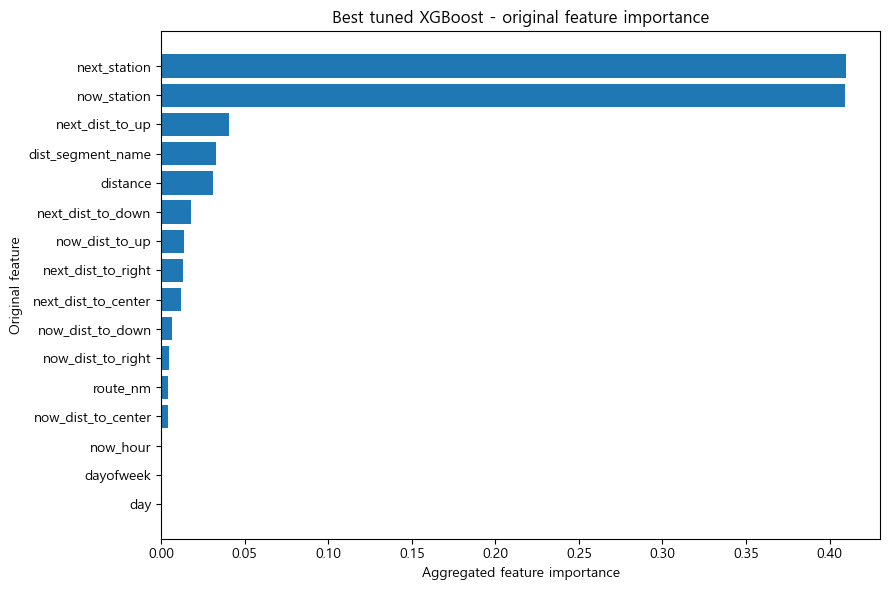

In [57]:
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    plot_grouped_df = grouped_importance_df.sort_values("importance")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_grouped_df["original_feature"], plot_grouped_df["importance"])
    plt.xlabel("Aggregated feature importance")
    plt.ylabel("Original feature")
    plt.title("Best tuned XGBoost - original feature importance")
    plt.tight_layout()
    plt.show()

In [58]:
os.environ["GDFONTPATH"] = r"C:\Windows\Fonts"

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

tree_index = 0

dtreeviz_svg_path = os.path.join(
    output_dir,
    f"xgboost_dtreeviz_tree_{tree_index}.svg"
)

dtreeviz_svg_path

'outputs\\xgboost_dtreeviz_tree_0.svg'

In [59]:
transformed_feature_names = list(best_preprocessor.get_feature_names_out())

transformed_feature_names

['cat__route_nm_201-11',
 'cat__route_nm_201-12',
 'cat__route_nm_201-13',
 'cat__route_nm_201-14',
 'cat__route_nm_201-15',
 'cat__route_nm_201-16',
 'cat__route_nm_201-17',
 'cat__route_nm_201-18',
 'cat__route_nm_201-21',
 'cat__route_nm_201-22',
 'cat__route_nm_201-24',
 'cat__route_nm_201-26',
 'cat__route_nm_201-27',
 'cat__route_nm_281-1',
 'cat__route_nm_281-2',
 'cat__route_nm_360-1',
 'cat__route_nm_360-12',
 'cat__route_nm_360-2',
 'cat__route_nm_360-7',
 'cat__route_nm_365-21',
 'cat__route_nm_365-22',
 'cat__now_station_911의원',
 'cat__now_station_LH아파트',
 'cat__now_station_가마초등학교',
 'cat__now_station_가흥동',
 'cat__now_station_거로 입구',
 'cat__now_station_견월교',
 'cat__now_station_계룡동',
 'cat__now_station_고도농원',
 'cat__now_station_고래왓',
 'cat__now_station_고망난돌입구',
 'cat__now_station_고산동산(광양방면)',
 'cat__now_station_고산동산(아라방면)',
 'cat__now_station_고성리 구 성산농협',
 'cat__now_station_고성리 성산농협',
 'cat__now_station_고성리제주은행',
 'cat__now_station_고성오일시장',
 'cat__now_station_고으니모르 국립제주박물관',

In [60]:
short_feature_names = []

for name in transformed_feature_names:
    short_name = (
        name
        .replace("cat__route_nm_", "route_")
        .replace("cat__now_station_", "now_")
        .replace("cat__next_station_", "next_")
        .replace("cat__dist_segment_name_", "segment_")
        .replace("remainder__", "")
    )
    short_feature_names.append(short_name)

short_feature_names

['route_201-11',
 'route_201-12',
 'route_201-13',
 'route_201-14',
 'route_201-15',
 'route_201-16',
 'route_201-17',
 'route_201-18',
 'route_201-21',
 'route_201-22',
 'route_201-24',
 'route_201-26',
 'route_201-27',
 'route_281-1',
 'route_281-2',
 'route_360-1',
 'route_360-12',
 'route_360-2',
 'route_360-7',
 'route_365-21',
 'route_365-22',
 'now_911의원',
 'now_LH아파트',
 'now_가마초등학교',
 'now_가흥동',
 'now_거로 입구',
 'now_견월교',
 'now_계룡동',
 'now_고도농원',
 'now_고래왓',
 'now_고망난돌입구',
 'now_고산동산(광양방면)',
 'now_고산동산(아라방면)',
 'now_고성리 구 성산농협',
 'now_고성리 성산농협',
 'now_고성리제주은행',
 'now_고성오일시장',
 'now_고으니모르 국립제주박물관',
 'now_공업단지 입구',
 'now_공천포',
 'now_관덕정',
 'now_광대왓',
 'now_광양',
 'now_광양사거리',
 'now_광지동',
 'now_광치기해변',
 'now_교래입구',
 'now_구 터미널',
 'now_구좌보건지소',
 'now_구좌중앙초등학교',
 'now_국립제주박물관',
 'now_그린카센터',
 'now_금붕사',
 'now_금산목',
 'now_김녕리',
 'now_김녕해수욕장',
 'now_김녕환승정류장(김녕초등학교)',
 'now_꽃동산',
 'now_난산입구',
 'now_난산입구(성산기상대)',
 'now_남국사',
 'now_남국원(광양방면)',
 'now_남국원(아라방면)',
 'now_남녕고등학교',
 'now_남서광마을',

In [61]:
# 3. dtreeviz용 학습 데이터 생성
# 전체 X_train을 전처리 합니다.
# OneHotEncoder 결과가 sparse matrix일 수 있으므로,
# XGBoost 학습용으로 DataFrame을 만들기 위해 dense로 변환합니다.
X_train_transformed = best_preprocessor.transform(X_train)
X_train_transformed = X_train_transformed.toarray()
X_train_viz_df = pd.DataFrame(
    X_train_transformed,
    columns=short_feature_names,
    index=X_train.index
)

print("dtreeviz용 학습 데이터 shape:", X_train_viz_df.shape)

dtreeviz용 학습 데이터 shape: (166684, 743)


In [62]:
# 4. 기존 최적 XGBoost 파라미터 가져오기
best_xgb_params = best_xgb_model.get_params()

viz_xgb_model = XGBRegressor(**best_xgb_params)

In [63]:
# 5. feature명이 있는 dataFrame으로 시각화 전용 모델 학습
viz_xgb_model.fit(
    X_train_viz_df,
    y_train
)

print("dtreeviz용 XGBoost 모델 학습 완료")
print("booster feature_names 예시:")
print(viz_xgb_model.get_booster().feature_names[:20])

dtreeviz용 XGBoost 모델 학습 완료
booster feature_names 예시:
['route_201-11', 'route_201-12', 'route_201-13', 'route_201-14', 'route_201-15', 'route_201-16', 'route_201-17', 'route_201-18', 'route_201-21', 'route_201-22', 'route_201-24', 'route_201-26', 'route_201-27', 'route_281-1', 'route_281-2', 'route_360-1', 'route_360-12', 'route_360-2', 'route_360-7', 'route_365-21']


In [64]:
# 6. dtreeviz용 샘플 데이터 준비
sample_size = min(1000, len(X_train_viz_df))
X_train_viz_sample = X_train_viz_df.sample(
    n=sample_size,
    random_state=42
)

y_train_viz_sample = y_train.loc[X_train_viz_sample.index]
print("dtreeviz 시각화용 생플 수:", len(X_train_viz_sample))

dtreeviz 시각화용 생플 수: 1000


In [65]:
from dtreeviz import model as dtreeviz_model
# 7. dtreeviz 생성
viz = dtreeviz_model(
    viz_xgb_model,
    X_train_viz_sample,
    y_train_viz_sample,
    feature_names=list(X_train_viz_sample.columns),
    target_name=target_col,
    tree_index=tree_index
)

In [66]:
# 8. SVG 저장
# 현재 dreeviz 버전에서는 viz.view().save() 방식이 필요
viz_render = viz.view()
viz_render.save(dtreeviz_svg_path)
print("dtreeviz SVG 저장 완료:")
print(os.path.abspath(dtreeviz_svg_path))

dtreeviz SVG 저장 완료:
C:\ai_project01\outputs\xgboost_dtreeviz_tree_0.svg


In [67]:
# 9. SVG 내부에 한글 폰트 스타일 삽입
svg_file = Path(dtreeviz_svg_path)
svg_text = svg_file.read_text(encoding="utf-8")

korean_font_style = """
<style>
text {
font-family: "Malgun Gothic", "맑은 고딕", "Noto Sans CJK KR", sans-serif !important;
}
</style>
"""

# <svg ...> 태그 바로 뒤에 style 삽입
insert_pos = svg_text.find(">") + 1
svg_text = svg_text[:insert_pos] + korean_font_style + svg_text[insert_pos:]

svg_file.write_text(svg_text, encoding="utf-8")
print("SVG 파일에 한글 폰트 스타일을 추가했습니다.")

SVG 파일에 한글 폰트 스타일을 추가했습니다.


In [68]:
s = "  3people   unFollowed   me   "
s = s.split(" ")
s

['', '', '3people', '', '', 'unFollowed', '', '', 'me', '', '', '']